## Priprava tabele za analizo 

In [1]:
import pandas as pd
avti = pd.read_csv('avti.csv', index_col='id')
pd.options.display.max_rows = 20

In [2]:
avti.head(10)

,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Motor,Baterija,Starost
id,,,,,,,,,
22788645,Audi A6 Avant 40 TDI Sport S tronic 3x S-Line,24990.0,2019.0,162500 km,diesel motor,avtomatski menjalnik,"1968 ccm, 150 kW / 204 KM",NaN,NaN
22788618,Audi A7 3.0 TDI||Q||BI|TURBO||LUFT||MATRIX||HE...,23950.0,2015.0,226214 km,diesel motor,avtomatski menjalnik,"2967 ccm, 235 kW / 320 KM",NaN,NaN
22706867,Audi A4 Avant 2.0 TDI,10999.0,2016.0,209836 km,diesel motor,ročni menjalnik,"1968 ccm, 110 kW / 150 KM",NaN,NaN
22788576,Audi Q7 quattro 3.0 TDI S Line°7 SEDEŽ°KAMERA°...,14990.0,2012.0,316430 km,diesel motor,avtomatski menjalnik,"2967 ccm, 180 kW / 245 KM",NaN,NaN
22788555,Audi A3 1.6 TDI S Line LED-NAVIGACIJA-18 COL-P...,9999.0,2016.0,245640 km,diesel motor,ročni menjalnik,"1598 ccm, 81 kW / 110 KM",NaN,NaN
22788521,Audi A3 Limuzina 2.0TDI Advanced S tronic+MATR...,21970.0,2024.0,124277 km,diesel motor,avtomatski menjalnik,"1968 ccm, 85 kW / 116 KM",NaN,NaN
22788506,Audi A6 2.7 TDI EURO 5,3999.0,2008.0,350000 km,diesel motor,avtomatski menjalnik,"2698 ccm, 140 kW / 190 KM",NaN,NaN
22788502,Audi A3 2.0TDI-Sport-Acc-Led-D select-Key Go-M...,13950.0,2017.0,199800 km,diesel motor,avtomatski menjalnik,"1968 ccm, 110 kW / 150 KM",NaN,NaN
22788497,Audi A6 3.0 TDI LIMUZINA S-LINE XENON-GRETJE S...,8850.0,2013.0,295797 km,diesel motor,ročni menjalnik,"2967 ccm, 150 kW / 204 KM",NaN,NaN


Za lažje delo s podatki, bomo spremenili nekatere stolpce v tabeli in poudarili nekatere podatke s katerimi želimo opravljati več primerjav.

Želimo izolirane podatke o *moči* in *prostornini* motorja, ter podatke o *gorivu* in *menjalniku* zapisane z eno besedo za lažjo primerjavo in filtriranje.

In [3]:
import re
avti['prostornina'] = avti['Motor'].str.extract(r'(\d+) ccm', expand=False).astype(float)
avti['moč'] = avti['Motor'].str.extract(r'(\d+) KM', expand=False).astype(float)
avti = avti.drop(columns=['Motor'])
avti['Gorivo'] = avti['Gorivo'].str.extract(r'(\w+) \w+', expand=False)
avti['Menjalnik'] = avti['Menjalnik'].str.extract(r'(\w+) \w+', expand=False)
avti['Prevoženih'] = avti['Prevoženih'].str.replace(' km', '').astype(float)
avti.head(10)

,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč
id,,,,,,,,,,
22788645,Audi A6 Avant 40 TDI Sport S tronic 3x S-Line,24990.0,2019.0,162500.0,diesel,avtomatski,NaN,NaN,1968.0,204.0
22788618,Audi A7 3.0 TDI||Q||BI|TURBO||LUFT||MATRIX||HE...,23950.0,2015.0,226214.0,diesel,avtomatski,NaN,NaN,2967.0,320.0
22706867,Audi A4 Avant 2.0 TDI,10999.0,2016.0,209836.0,diesel,ročni,NaN,NaN,1968.0,150.0
22788576,Audi Q7 quattro 3.0 TDI S Line°7 SEDEŽ°KAMERA°...,14990.0,2012.0,316430.0,diesel,avtomatski,NaN,NaN,2967.0,245.0
22788555,Audi A3 1.6 TDI S Line LED-NAVIGACIJA-18 COL-P...,9999.0,2016.0,245640.0,diesel,ročni,NaN,NaN,1598.0,110.0
22788521,Audi A3 Limuzina 2.0TDI Advanced S tronic+MATR...,21970.0,2024.0,124277.0,diesel,avtomatski,NaN,NaN,1968.0,116.0
22788506,Audi A6 2.7 TDI EURO 5,3999.0,2008.0,350000.0,diesel,avtomatski,NaN,NaN,2698.0,190.0
22788502,Audi A3 2.0TDI-Sport-Acc-Led-D select-Key Go-M...,13950.0,2017.0,199800.0,diesel,avtomatski,NaN,NaN,1968.0,150.0
22788497,Audi A6 3.0 TDI LIMUZINA S-LINE XENON-GRETJE S...,8850.0,2013.0,295797.0,diesel,ročni,NaN,NaN,2967.0,204.0


Analizirali bomo nekaj dejstev o rabljenih avtih in pogledali kako najti avto ki kupcu najbolj ustreza. Nato si bomo ogledali več različnih primerjav med tremi znamkami glede na različne vrednosti ki jih imamo na razpolago v tabeli.

Začnimo z nekaj **primerjavami glede na ceno**.

In [4]:
avti.sort_values('cena')

,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč
id,,,,,,,,,,
22784393,Audi A6 2.5 V6 TDI Tiptronic QUATTRO 4x4,390.0,2000.0,320000.0,diesel,avtomatski,NaN,NaN,2496.0,150.0
22772990,Mercedes-Benz C-Razred C 200 CDI Classic,800.0,2004.0,490000.0,diesel,ročni,NaN,NaN,2148.0,122.0
22781105,Mercedes-Benz 190 E 2.0,800.0,1989.0,NaN,bencinski,ročni,NaN,NaN,1997.0,118.0
22784365,Audi A6 2.4 V6,880.0,2005.0,318000.0,bencinski,ročni,NaN,NaN,2393.0,177.0
22764516,Mercedes-Benz E-Razred E 270 CDI Elegance,990.0,2001.0,350000.0,diesel,ročni,NaN,NaN,2685.0,170.0
...,...,...,...,...,...,...,...,...,...,...
22631264,Mercedes-Benz GLC-Razred GLC 450d 4MATIC AMG L...,NaN,2025.0,13401.0,diesel,avtomatski,NaN,NaN,2989.0,367.0
22064871,Mercedes-Benz GLC coupe 200 4MATIC FULL AMG LI...,NaN,2025.0,9603.0,bencinski,avtomatski,NaN,NaN,1999.0,204.0
22786724,Mercedes-Benz S-Razred AMG S 63 4MATIC dolgi |...,NaN,2016.0,217777.0,bencinski,avtomatski,NaN,NaN,5461.0,585.0


Vidimo da nastane **problem** z vsemi oglasi na katerih niso podani točni podatki o ceni. Tak vzorec se ponavlja tudi pri drugih vrednostih kot so prevoženi kilometri, letnik 1. regstracije in starost. Razlog je, da v oglasih na avtonetu te podatki niso vedno nujni in so lahko v celoti izpuščeni, oziroma pri primeru cene je lahko namesto trdne vrednosti zapisano 'Pokličite za ceno'.

Da se izognemo oglasom ki ne vsebujejo podatkov s kateri želimo delati primerjave bomo namesto tabele avti analizirali novo tabelo kjer so vse cene dejansko navedene.

In [5]:
avti_s_ceno = avti[avti['cena'].notna()]
avti_s_ceno.sort_values('cena')

,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč
id,,,,,,,,,,
22784393,Audi A6 2.5 V6 TDI Tiptronic QUATTRO 4x4,390.0,2000.0,320000.0,diesel,avtomatski,NaN,NaN,2496.0,150.0
22772990,Mercedes-Benz C-Razred C 200 CDI Classic,800.0,2004.0,490000.0,diesel,ročni,NaN,NaN,2148.0,122.0
22781105,Mercedes-Benz 190 E 2.0,800.0,1989.0,NaN,bencinski,ročni,NaN,NaN,1997.0,118.0
22784365,Audi A6 2.4 V6,880.0,2005.0,318000.0,bencinski,ročni,NaN,NaN,2393.0,177.0
22764516,Mercedes-Benz E-Razred E 270 CDI Elegance,990.0,2001.0,350000.0,diesel,ročni,NaN,NaN,2685.0,170.0
...,...,...,...,...,...,...,...,...,...,...
22648357,Mercedes-Benz G-Razred AMG G 63,271305.0,NaN,NaN,bencinski,avtomatski,NaN,NOVO,3982.0,585.0
22764532,Mercedes-Benz G-Razred SUPERIOR+PERFORM.+NIGHT...,275397.0,2026.0,20.0,bencinski,avtomatski,NaN,NaN,3982.0,585.0
22237756,Mercedes-Benz G-Razred Mercedes-AMG G 63 MY26-...,279000.0,NaN,NaN,bencinski,avtomatski,NaN,NOVO,3982.0,585.0


Iz zgornjega rezultata vidimo nov **problem**, ki nastane pri analizi prevoženih kilometrov in letnika prve registracije.

Za letnik ni potrebno narediti nove tabele, ampak za lepšo predstavitev podatkov lahko nastavimo vse vrednosti NaN na `0`, kajti gre za obvezen podatek, ki mora biti na vsakem oglasu naveden, razen če avto nikoli ni bil registriran (kar efektivno pomeni da je nov), takrat je vrednost nastavljena na `/`. 

Pri prevoženih kilometrih naletimo na *dve različni* možnosti. Lahko oglaševalec zadrži informacije zase ali gre dejasnko za nov avto ki še nima prevoženih kilometrov. Zaradi tega moramo ločiti dve možnosti in vsako obravnavati posebej. 

In [6]:
avti.loc[avti['Starost'] == 'NOVO', 'Prevoženih'] = 0

# v originalni tabeli nastavimo vrednost prevoženih kilometrov vseh novih avtov na 0. Enako naredimo za letnik 1. registracije

avti.loc[avti['Starost'] == 'NOVO', '1.registracija'] = 2026
avti.sort_values('1.registracija')

,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč
id,,,,,,,,,,
21425826,Mercedes-Benz - 280 SE Coupe 3.5 V8,97990.0,1971.0,76675.0,bencinski,avtomatski,NaN,NaN,3459.0,200.0
22773795,Mercedes-Benz W123 200 D,12000.0,1979.0,250000.0,diesel,ročni,NaN,NaN,1988.0,56.0
22783633,BMW serija 3: 320i,17100.0,1986.0,167000.0,bencinski,ročni,NaN,NaN,1990.0,129.0
22780836,Audi 80 1.6,1000.0,1987.0,250000.0,bencinski,ročni,NaN,NaN,1595.0,75.0
22781105,Mercedes-Benz 190 E 2.0,800.0,1989.0,NaN,bencinski,ročni,NaN,NaN,1997.0,118.0
...,...,...,...,...,...,...,...,...,...,...
21755842,Mercedes-Benz GLC-Razred GLC 220 d 4MATIC,74426.0,2026.0,0.0,diesel,avtomatski,NaN,NOVO,1993.0,197.0
22622849,Audi Q7 quattro 220 kW - NOVI MODEL - V PRIHOD...,NaN,2026.0,0.0,diesel,avtomatski,NaN,NOVO,2967.0,299.0
22622700,Audi Q7 quattro 220 kW - NOVI MODEL -V PRIHOD...,NaN,2026.0,0.0,diesel,avtomatski,NaN,NOVO,2967.0,299.0


Sedaj so vsi podatki pripravljeni na analizo. Preden lahko primerjamo rezultate med tremi znamkami moramo dodati nov stolpec `Znamke`. 

Tu se lahko zanašamo na dejstvo da je prva beseda v imenu vsakega oglasa znamka avta, kar je standard vseh oglasov na avto.net.

In [7]:
avti['Znamke'] = avti['ime'].str.extract(r'(\w+)', expand=False).astype(str)

avti_s_ceno = avti[avti['cena'].notna()]

# še enkrat poženemo isto kodo da posodobimo avti_s_ceno z novim stolpcem Znamke

avti_po_znamkah = avti.groupby('Znamke')
avti_po_znamkah.head()

,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč,Znamke
id,,,,,,,,,,,
22788645,Audi A6 Avant 40 TDI Sport S tronic 3x S-Line,24990.0,2019.0,162500.0,diesel,avtomatski,NaN,NaN,1968.0,204.0,Audi
22788618,Audi A7 3.0 TDI||Q||BI|TURBO||LUFT||MATRIX||HE...,23950.0,2015.0,226214.0,diesel,avtomatski,NaN,NaN,2967.0,320.0,Audi
22706867,Audi A4 Avant 2.0 TDI,10999.0,2016.0,209836.0,diesel,ročni,NaN,NaN,1968.0,150.0,Audi
22788576,Audi Q7 quattro 3.0 TDI S Line°7 SEDEŽ°KAMERA°...,14990.0,2012.0,316430.0,diesel,avtomatski,NaN,NaN,2967.0,245.0,Audi
22788555,Audi A3 1.6 TDI S Line LED-NAVIGACIJA-18 COL-P...,9999.0,2016.0,245640.0,diesel,ročni,NaN,NaN,1598.0,110.0,Audi
22790385,BMW serija 3: 330d xDrive M-SPORT|Pano|ACC|360...,53990.0,2025.0,14500.0,diesel,avtomatski,NaN,NaN,2993.0,286.0,BMW
22790370,BMW serija X5: xD40d|M|Laser|Zračno|ACC|360K|M...,55990.0,2021.0,95000.0,diesel,avtomatski,NaN,NaN,2993.0,340.0,BMW
22790333,BMW serija X5: 30d XD MSPORT|360KAM|ACC|HK|NAV...,40590.0,2019.0,168190.0,diesel,avtomatski,NaN,NaN,2993.0,265.0,BMW
22790293,BMW serija X5: xDrive30d M PRO ICONIC HEAD UP ...,85900.0,2024.0,36000.0,diesel,avtomatski,NaN,NaN,2993.0,298.0,BMW


## Analiza

*Poglejmo katere znamke in kateri avti ustrezajo različnim tipom strank.*

Prvi kupec bo Charles. Njegov prvi avto je bil VW Polo in po treh letih išče nadomestilo. Želi močan avto, ampak je omejen na največ 20.000€. Vse ostale lastnosti avta ga ne zanimajo. Ker je Charles študent in si ne želi izposoditi preveč denarja za ta nakup, bo izbiral med najcenejšimi avti ki ustrezajo njegovim željam.

Želje: cena < 20.000 €, moč > 300 KM

In [8]:
Charles = avti_s_ceno[(avti_s_ceno.cena < 20000) & (avti_s_ceno.moč > 300)]
print(Charles.groupby('Znamke').size())
Charles.sort_values('cena')

Znamke
Audi    5
BMW     3
dtype: int64


,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč,Znamke
id,,,,,,,,,,,
22784914,Audi S3 quattro 2.0 TFSI,10500.0,2009.0,310000.0,bencinski,ročni,NaN,NaN,1984.0,349.0,Audi
22775383,Audi Q7 quattro 4.2 TDI Sport Tiptronic-LEANPA...,10990.0,2009.0,323000.0,diesel,avtomatski,NaN,NaN,4134.0,340.0,Audi
22593137,Audi A8 4.2 TDI-385 KS-QUATTRO-VSA OPREMA-OPOMBE,12999.0,2015.0,293371.0,diesel,avtomatski,NaN,NaN,4134.0,385.0,Audi
21999983,BMW serija 6 Gran Coupe: INDIVIDUAL-M SPORT-SL...,13999.0,2012.0,259149.0,diesel,avtomatski,NaN,NaN,2993.0,313.0,BMW
22523276,Audi A5 Q 3.0TFSI 400HP SUPERCHARGED|VELIK SER...,15700.0,2015.0,221500.0,bencinski,avtomatski,NaN,NaN,2995.0,401.0,Audi
22790203,BMW serija 7: 750Ld xDrive - INDIVIDUAL - PROT...,17000.0,2014.0,361000.0,diesel,avtomatski,NaN,NaN,2993.0,381.0,BMW
22783720,BMW serija 5: 535i xDrive Avt.,17500.0,2013.0,220000.0,bencinski,avtomatski,NaN,NaN,2979.0,306.0,BMW
22784543,Audi A6 Avant 3.0 TDI QUATTRO-235KW-BI-TURBO-...,18295.0,2015.0,258630.0,diesel,avtomatski,NaN,NaN,2967.0,320.0,Audi


Fernando je starejši in bolj umirjen voznik. Za razliko od Charlesa si lahko privošči dražji avto, ampak ima nekoliko več želja.

Želje: cena < 80.000 €, prevoženi < 50.000 km, letnik > 2018, pogon = hibridni ali elektro.

In [9]:
Fernando = avti_s_ceno[(avti_s_ceno.cena < 80000) & (avti_s_ceno.Prevoženih < 50000) & (avti_s_ceno['1.registracija'] > 2018) & (avti_s_ceno.Gorivo.isin(['hibridni', 'elektro']))]
print(Fernando.groupby('Znamke').size())
Fernando.sort_values(['cena'], ascending=False)

Znamke
Audi        23
BMW         15
Mercedes    15
dtype: int64


,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč,Znamke
id,,,,,,,,,,,
22184007,Mercedes-Benz GLB-Razred GLB 250+ z EQ TEHNOLO...,77338.0,2026.0,0.0,elektro,NaN,85 kWh,NOVO,NaN,NaN,Mercedes
21662783,Mercedes-Benz EQS 450 4Matic - Electric Art - ...,74990.0,2023.0,49000.0,elektro,NaN,"108,4 kWh",NaN,NaN,NaN,Mercedes
22787104,Mercedes-Benz CLA-Razred CLA 350 4MATIC EQ Tec...,73925.0,2026.0,6600.0,elektro,NaN,85 kWh,NaN,NaN,NaN,Mercedes
21675150,Audi Q8 55 TFSI e quattro tiptr. 290kW Business,71990.0,2026.0,0.0,hibridni,avtomatski,NaN,NOVO,2995.0,394.0,Audi
22233773,Audi A6 Sportback e-tron quattro Business,71486.0,2026.0,0.0,elektro,NaN,100 kWh,NOVO,NaN,NaN,Audi
...,...,...,...,...,...,...,...,...,...,...,...
22774660,BMW iX1 xDrive30 |M-Sport|ACC|Pano|HUD|Harman|...,41990.0,2023.0,33400.0,elektro,NaN,"64,7 kWh",NaN,NaN,NaN,BMW
22781222,Audi e-tron Sportback 55 quattro S line.NEMŠKI...,39999.0,2022.0,49000.0,elektro,NaN,95 kWh,NaN,NaN,NaN,Audi
22680155,Mercedes-Benz GLA-Razred 250 e Avt.KAMERA.NAVI...,31999.0,2021.0,49000.0,hibridni,avtomatski,NaN,NaN,1332.0,160.0,Mercedes


Lando je pred kratkim zadel na loteriji in osvojil ogromno denarja. Ker ne ve kaj narediti z vsem denarjem in pametnejše stvari kot investiranje njemu niso zanimive, se je odločil da bo kupil čim dražji avto da naredi dober vtis. Poleg visoke cene mora biti avto tudi zmogljiv.

Želje: cena > 130.000 €, moč > 600 KM

In [10]:
Lando = avti_s_ceno[(avti_s_ceno.cena > 130000) & (avti_s_ceno.moč > 600)]
print(Lando.groupby('Znamke').size())
Lando.sort_values('cena')

Znamke
BMW          1
Mercedes    12
dtype: int64


,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč,Znamke
id,,,,,,,,,,,
22727741,BMW M5 BMW M5 TOURING G99 | COMFORT | B W | PA...,131000.0,2026.0,0.0,hibridni,avtomatski,NaN,NOVO,4395.0,726.0,BMW
22347595,Mercedes-Benz GLE-Razred AMG GLE 63 S 4MATIC+ ...,134990.0,2024.0,44000.0,bencinski,avtomatski,NaN,NaN,3982.0,612.0,Mercedes
17121395,Mercedes-Benz S-Razred S 63 AMG 4MATIC+ L,144900.0,2020.0,62000.0,bencinski,avtomatski,NaN,NaN,3982.0,612.0,Mercedes
20083345,Mercedes-Benz G-Razred BRABUS-AMG63-22C-PANORA...,149990.0,2018.0,150000.0,bencinski,avtomatski,NaN,NaN,5461.0,620.0,Mercedes
21081163,Mercedes-Benz S-Razred Mercedes Maybach S 680 ...,150000.0,2024.0,100000.0,bencinski,avtomatski,NaN,NaN,5980.0,612.0,Mercedes
22602963,Mercedes-Benz GLE-Razred AMG 53 e 4MATIC PREMI...,170000.0,2026.0,4000.0,bencinski,avtomatski,NaN,NaN,2999.0,605.0,Mercedes
22607806,Mercedes-Benz GLE-Razred AMG 53 e 4MATIC PREMI...,175000.0,2026.0,4001.0,hibridni,avtomatski,NaN,NaN,2999.0,605.0,Mercedes
22671584,Mercedes-Benz GLE-Razred 53 e 4MATIC PREMIUM PLUS,175000.0,2026.0,1000.0,hibridni,avtomatski,NaN,NaN,2999.0,605.0,Mercedes
22136129,Mercedes-Benz S-Razred Mercedes-AMG S 63E Perf...,189900.0,2024.0,15490.0,hibridni,avtomatski,NaN,NaN,3982.0,802.0,Mercedes


Splošno znano dejstvo je da nakup avta velja za slabo investicijo. Za razliko od na primer nepremičnin, avti s časom in vsakim prevoženim kilometrom izgubljajo na svoji vrednosti, kar pogosto odvrača ljudi od nakupa avtomobilov kot investicijskih naložb. Vendar obstajajo izjeme in zbiratelji avtomobilov, katerih naloga je iskanje takih primerkov, ki bodo kar se da dobro obdržali vrednost kljub letom in morda celo rasli v vrednosti.

Stalni nakupi takih zbirateljev so ponavadi avti prestižnih znamk kot so Ferrari, Aston Martin, McLaren in podobni. Ker naši podatki in slovenski trg rabljenih avtomobilov ne zajema podobnih znamk, takih primerov ni veliko, ampak se kljub temu pojavijo. 

*Trdimo da se v naši tabeli skriva nekaj primerkov avtov ki so čez leta obdržali svojo vrednost.*

In [11]:
avti_s_ceno[(avti_s_ceno['1.registracija'] < 1980) & (avti_s_ceno.cena > 90000)].sort_values('cena')

,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč,Znamke
id,,,,,,,,,,,
21425826,Mercedes-Benz - 280 SE Coupe 3.5 V8,97990.0,1971.0,76675.0,bencinski,avtomatski,NaN,NaN,3459.0,200.0,Mercedes


Rezultati nakazujejo, da je med nemškimi avtomobili Mercedes edini na katerega se splača staviti na dolgi rok, kar se tudi ujema z dejanskimi dejstvi. Skozi leta je bil Mercedes edini nemški predstavnik na težje dostopnih prestižnih dražbah in zadnjih nekaj let tudi drži rekord za najdražji avto prodan na dražbi (143.000.000 €, MB 300 SLR coupe).

### Primerjave znamk

To da je Mercedes najbolj prestižna znamka med tremi potrjuje tudi povprečna cena rabljenega avtomobila na trgu in v katerem cenovnem razredu prevladuje katera znamka. Spodaj bo vidno da Audi prevladuje trg cenejših avtomobilov, medtem ko Mercedes prevladuje pri višjih cenah.

In [12]:
avti_po_znamkah.cena.mean()

Znamke
Audi        48275.517241
BMW         58368.265487
Mercedes    69534.179372
Name: cena, dtype: float64

In [ ]:
avti_s_ceno['Razred'] = (avti_s_ceno['cena'] // 20000) * 20000  # nastavimo cenovne razrede na vsakih 20.000 €
print(avti_s_ceno.groupby(['Razred', 'Znamke']).size())
avti_s_ceno.sort_values('Razred')

Razred    Znamke  
0.0       Audi        88
          BMW         99
          Mercedes    82
20000.0   Audi        71
          BMW         71
                      ..
220000.0  Mercedes     6
240000.0  Mercedes     2
260000.0  Mercedes     6
280000.0  Mercedes     1
300000.0  Mercedes     1
Length: 35, dtype: int64


,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč,Znamke,Razred
id,,,,,,,,,,,,
22788198,Audi A6 Avant 3.0TDI-S Line-S tronic-Matrix-Ac...,12950.0,2015.0,315200.0,diesel,avtomatski,NaN,NaN,2967.0,218.0,Audi,0.0
22788194,Audi A3 2.0 TDI,2323.0,2006.0,408408.0,diesel,ročni,NaN,NaN,1968.0,140.0,Audi,0.0
22786841,BMW serija 3 Touring: 318d Touring Sport Line ...,9980.0,2017.0,285081.0,diesel,avtomatski,NaN,NaN,1995.0,150.0,BMW,0.0
22786815,BMW serija 3: 318d - LINE ASSIST - USNJE - FUL...,19990.0,2019.0,158106.0,diesel,ročni,NaN,NaN,1995.0,150.0,BMW,0.0
21999983,BMW serija 6 Gran Coupe: INDIVIDUAL-M SPORT-SL...,13999.0,2012.0,259149.0,diesel,avtomatski,NaN,NaN,2993.0,313.0,BMW,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
22696033,Mercedes-Benz G-Razred Mercedes-AMG G 63 FACEL...,269000.0,2026.0,0.0,bencinski,avtomatski,NaN,NOVO,3982.0,585.0,Mercedes,260000.0
22741426,Mercedes-Benz G-Razred G63-AMG-V8-FACELIFT-MAN...,269995.0,2026.0,0.0,bencinski,avtomatski,NaN,NOVO,3982.0,585.0,Mercedes,260000.0
22648357,Mercedes-Benz G-Razred AMG G 63,271305.0,2026.0,0.0,bencinski,avtomatski,NaN,NOVO,3982.0,585.0,Mercedes,260000.0


#### Cenovni razredi ####

Poglejmo kaj vsaka znamka ponuja na določenem **cenovnem razredu**. Ogledali si bomo tri razrede: *upper middle* (`upr_mdl`), *upper* (`upr`), *lower middle* (`lwr_mdl`). Da vidimo katera znamka ponuja 'več avta' v vsakem cenovnem razredu bomo dodali nekaj dodatnih omejitev in **primerjali število oglasov na znamko pred in po dodanih omejitvah.**

In [24]:
upr_midl = avti_s_ceno[(avti_s_ceno.Razred == 80000) & (avti_s_ceno.moč > 400) & (avti_s_ceno['1.registracija'] > 2022)]
mdl_razred = avti_s_ceno[avti_s_ceno.Razred == 80000]
print(mdl_razred.groupby('Znamke').size())
print (upr_midl.groupby('Znamke').size())
upr_midl.sort_values(['moč'], ascending=False)

Znamke
Audi        33
BMW         55
Mercedes    51
dtype: int64
Znamke
Audi         4
BMW         15
Mercedes     5
dtype: int64


,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč,Znamke,Razred
id,,,,,,,,,,,,
22781750,BMW XM 4.4 V8 xDrive Iconic-Bowers-360Kamere-S...,93880.0,2023.0,76861.0,hibridni,avtomatski,NaN,NaN,4395.0,653.0,BMW,80000.0
22717955,Audi RS6 Avant RS6 Perform.TFSI quattro tiptro...,99999.0,2023.0,73000.0,bencinski,avtomatski,NaN,NaN,3996.0,630.0,Audi,80000.0
22436816,BMW M8 Coupe Competition xDrive - 1 last SLO -,88870.0,2023.0,24075.0,bencinski,avtomatski,NaN,NaN,4395.0,625.0,BMW,80000.0
22633829,Audi RS6 Avant TFSI Quattro,98000.0,2023.0,105000.0,bencinski,avtomatski,NaN,NaN,3996.0,600.0,Audi,80000.0
22467287,Audi RS Q8 Matrix LED zračn.vzmet. Headup kera...,94900.0,2023.0,76698.0,bencinski,avtomatski,NaN,NaN,3996.0,600.0,Audi,80000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
22534357,Audi SQ8 TFSI quattro Tiptronic vsa možna oprema,94900.0,2024.0,34455.0,bencinski,avtomatski,NaN,NaN,3996.0,507.0,Audi,80000.0
22716026,Mercedes-Benz GLE-Razred GLE 580-V8 4MATIC-AIR...,89300.0,2023.0,21900.0,bencinski,avtomatski,NaN,NaN,3982.0,489.0,Mercedes,80000.0
22682351,Mercedes-Benz CLE-Razred AMG Coupe 53 4MATIC+ ...,89990.0,2026.0,3000.0,bencinski,avtomatski,NaN,NaN,2999.0,449.0,Mercedes,80000.0


In [23]:
upr = avti_s_ceno[(avti_s_ceno.Razred > 100000) & (avti_s_ceno.moč > 500) & (avti_s_ceno['1.registracija'] > 2022)]
upr_razred = avti_s_ceno[avti_s_ceno.Razred > 100000]
print(upr_razred.groupby('Znamke').size())
print (upr.groupby('Znamke').size())
upr.sort_values(['moč'], ascending=False)

Znamke
Audi        12
BMW         42
Mercedes    69
dtype: int64
Znamke
Audi         2
BMW         14
Mercedes    36
dtype: int64


,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč,Znamke,Razred
id,,,,,,,,,,,,
22063972,Mercedes-Benz S-Razred S63-AMG-L-805KM-E-PERFO...,189995.0,2024.0,11685.0,bencinski,avtomatski,NaN,NaN,3982.0,805.0,Mercedes,160000.0
22136129,Mercedes-Benz S-Razred Mercedes-AMG S 63E Perf...,189900.0,2024.0,15490.0,hibridni,avtomatski,NaN,NaN,3982.0,802.0,Mercedes,160000.0
22243007,BMW M5 MAT- keramika,126990.0,2025.0,25300.0,hibridni,avtomatski,NaN,NaN,4395.0,727.0,BMW,120000.0
22689248,BMW M5 Touring M Drivers Paket CARBON KAM360 M...,124990.0,2025.0,11400.0,bencinski,avtomatski,NaN,NaN,4395.0,727.0,BMW,120000.0
22544139,BMW M5 INDIVIDUAL-727KM-BOWERS-HLAJ-SED-LASER-...,129995.0,2025.0,17934.0,bencinski,avtomatski,NaN,NaN,4395.0,727.0,BMW,120000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
22724020,BMW M3 xDrive Competition | NA ZALOGI |,124530.0,2026.0,0.0,bencinski,avtomatski,NaN,NOVO,2993.0,530.0,BMW,120000.0
22736049,BMW M2 CS Coupe - NA ZALOGI,121229.0,2026.0,0.0,bencinski,avtomatski,NaN,NOVO,2993.0,530.0,BMW,120000.0
20301374,BMW M3 CS xDrive V FOLIJI KOT NOV,168115.0,2024.0,6000.0,bencinski,avtomatski,NaN,NaN,2993.0,530.0,BMW,160000.0


In [22]:
lwr_midl = avti_s_ceno[(avti_s_ceno.Razred == 40000) & (avti_s_ceno.moč > 250) & (avti_s_ceno['1.registracija'] > 2018)]
lwr_razred = avti_s_ceno[avti_s_ceno.Razred == 40000]
print(lwr_razred.groupby('Znamke').size())
print (lwr_midl.groupby('Znamke').size())
lwr_midl.sort_values(['moč'], ascending=False)

Znamke
Audi        99
BMW         79
Mercedes    77
dtype: int64
Znamke
Audi        59
BMW         44
Mercedes    27
dtype: int64


,ime,cena,1.registracija,Prevoženih,Gorivo,Menjalnik,Baterija,Starost,prostornina,moč,Znamke,Razred
id,,,,,,,,,,,,
22026948,Audi S8 4.0 TFSI QUATRO S LINE MATRIX 360 ZRAC...,52990.0,2021.0,171000.0,bencinski,avtomatski,NaN,NaN,3990.0,571.0,Audi,40000.0
22774224,BMW M4 Competiton Akrapovič,56500.0,2019.0,85000.0,bencinski,avtomatski,NaN,NaN,2979.0,515.0,BMW,40000.0
22774699,Mercedes-Benz C-Razred C63S-COUPE-AMG-PANO-KAM...,56885.0,2020.0,86948.0,bencinski,avtomatski,NaN,NaN,3982.0,510.0,Mercedes,40000.0
22769800,Mercedes-Benz GLE-Razred 580 4MATIC|Pano|ACC|Z...,59990.0,2020.0,130000.0,hibridni,avtomatski,NaN,NaN,3982.0,489.0,Mercedes,40000.0
22235183,Mercedes-Benz S-Razred S 63 AMG LOOK-PANO-ZRAC...,59990.0,2019.0,124000.0,bencinski,avtomatski,NaN,NaN,3982.0,469.0,Mercedes,40000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
22774565,BMW serija X7: xD30d|SoftC|Zračno|SkyL|Masaža|...,43990.0,2019.0,167000.0,diesel,avtomatski,NaN,NaN,2993.0,265.0,BMW,40000.0
21734061,BMW serija X6: AA LIMUZINA XDrive30D,51500.0,2020.0,70000.0,diesel,avtomatski,NaN,NaN,2993.0,265.0,BMW,40000.0
22774666,BMW serija X5: xDrive30d|M|Laser|Zračno|SoftC|...,53990.0,2021.0,116700.0,diesel,avtomatski,NaN,NaN,2993.0,265.0,BMW,40000.0


Rezultati te analize spet potrjujejo da se **Mercedes** bolj osredotoča na *prestižnejši* del industrije in tam tudi blesti, medtem ko se **Audi** znajde bolje pri *nižjih cenah*. **BMW** je znan bolj po *zmogljivosti* svojih avtomobilov ki jih prinesejo ob relativno dostopni ceni, kar je razvidno iz analize pri dominaciji BMW v upper middle razredu.

#### Grafična predstavitev ugotovitev

Oglejmo si nekaj **grafov** ki prikazujejo razporeditev oglasov glede na ceno in prevožene kilometre.

<Axes: xlabel='Razred'>

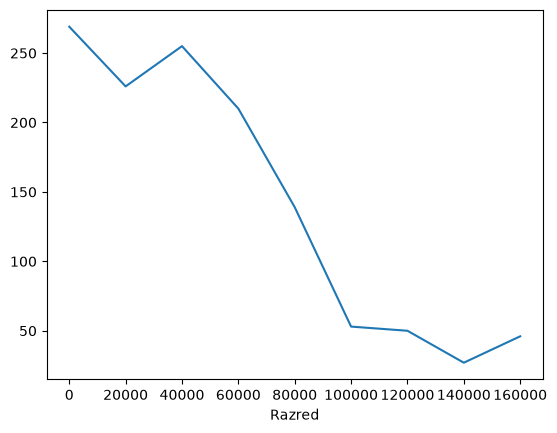

In [ ]:
import matplotlib.pyplot as plt

avti_s_ceno['Razred'] = avti_s_ceno['Razred'].clip(upper=160000) 
avti_s_ceno.groupby('Razred').size().plot()

<Axes: xlabel='1.registracija', ylabel='cena'>

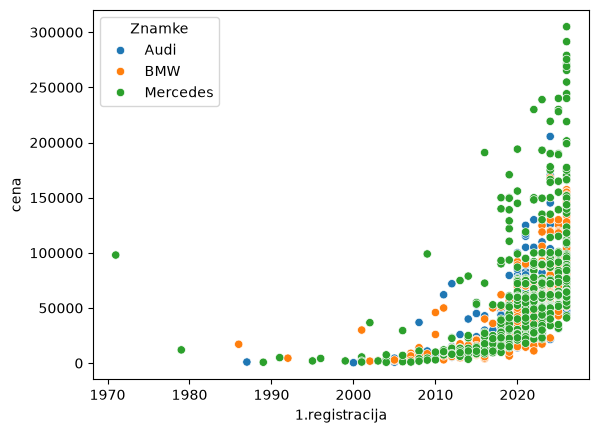

In [37]:
import seaborn as sns

# orodje da lahko predstavimo razlike med tremi znamkami grafično na enem grafu

sns.scatterplot(data=avti_s_ceno, x='1.registracija', y='cena', hue='Znamke')

<Axes: xlabel='Prevoženih', ylabel='cena'>

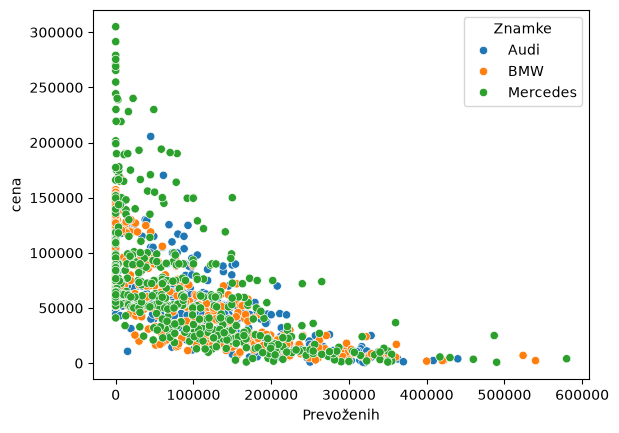

In [31]:
sns.scatterplot(data=avti_s_ceno, x='Prevoženih', y='cena', hue='Znamke')

Na **drugem** grafu vidimo potrditev da z leti lahko najbolj računamo na avte znamke Mercedes, kjer določeni modeli lepo ohranjajo vrednost.

Na **tretjem** grafu vidimo da se splošen padec cene, s prevoženimi kilometri odraža precej enakovredno ne vseh treh znamkah. BMW najhitreje pada po ceni, medtem ko ima Mercedes nekoliko več primerkov, kjer kljub veliki kilometrini avti še vedno ohranjajo dober del vrednosti.

## Povzetek ##

Z zgornjim programom si lahko pomagamo pri izbiri najbolj idealnega avta glede na naše želje, iščemo zanimive avte, ki ohranjajajo svojo vrednost skozi leta in tako načrtujemo našo naslednjo investicijo, ter primerjamo znamke glede na različne parametre.

Skupaj z vsebino `obdelava.py` lahko poljubne strani iz portala avto.net analiziramo na podoben način. Zaradi težav ki so razložene v tistem dokumentu, program vseeno zahteva nekoliko več ročnega dela ki postane zamuden, če želimo analizirati več 10.000 avtomobilov, v kolikor pa zadostuje tako število avtov kot je bilo uporabljeno tukaj, je ročnega dela občutno manj.